#  K-Means Clustering — Edición Pokémon

**Objetivo:** Aprender a agrupar datos sin etiquetas usando el algoritmo K-Means, aplicado a un mundo que ya conocemos: el universo Pokémon.

---

| Sección | Contenido |
|---|---|
| **Parte 1 — Demo** | Hábitats Pokémon con `make_blobs` |
| **Parte 2 — Laboratorio** | Método del Codo + Dataset de Bayas Pokémon |

## 📦 Importaciones

In [1]:
# Español: Importar las librerías necesarias
# English: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Español: Definir un estado aleatorio para reproducibilidad
# English: Define a random state for reproducibility
RANDOM_STATE = 42
print('✅ Librerías cargadas correctamente')


✅ Librerías cargadas correctamente


---
# 🎓 PARTE 1 — Descubriendo Hábitats Pokémon

Imagina que eres un investigador Pokémon con un sensor que captura la posición de cientos de Pokémon en la región.  
**No sabes de qué tipo son**, pero notas que se concentran en zonas. K-Means te ayudará a descubrir esas zonas automáticamente.

 **Pregunta clave:** ¿Puede un algoritmo encontrar grupos en datos que nunca ha visto etiquetados?

### 🗺️ Paso 1 — Generar los datos: 4 Hábitats Pokémon

In [2]:
# Español: Generamos 4 nubes de puntos que simulan hábitats Pokémon usando make_blobs
# English: Generate 4 clusters of points simulating Pokémon habitats using make_blobs
X, y_true = make_blobs(
    n_samples=300,       # Español: 300 avistamientos de Pokémon; English: 300 Pokémon sightings
    centers=4,           # Español: 4 hábitats distintos; English: 4 distinct habitats
    cluster_std=0.9,     # Español: dispersión dentro de cada hábitat; English: dispersion within each habitat
    random_state=RANDOM_STATE # Español: Semilla para reproducibilidad; English: Seed for reproducibility
)

print(f'Forma del dataset: {X.shape}')
print(f'Variables: coordenada X (longitud), coordenada Y (latitud)')
print(f'Primeras 5 observaciones:\n{X[:5]}')


Forma del dataset: (300, 2)
Variables: coordenada X (longitud), coordenada Y (latitud)
Primeras 5 observaciones:
[[ -9.25175257   6.55866298]
 [ -9.61269979   6.97742293]
 [ -1.7689072    7.91552684]
 [ -7.07554027  -5.89121043]
 [-10.67263984   6.41624524]]


C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\1562370674.py:9: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


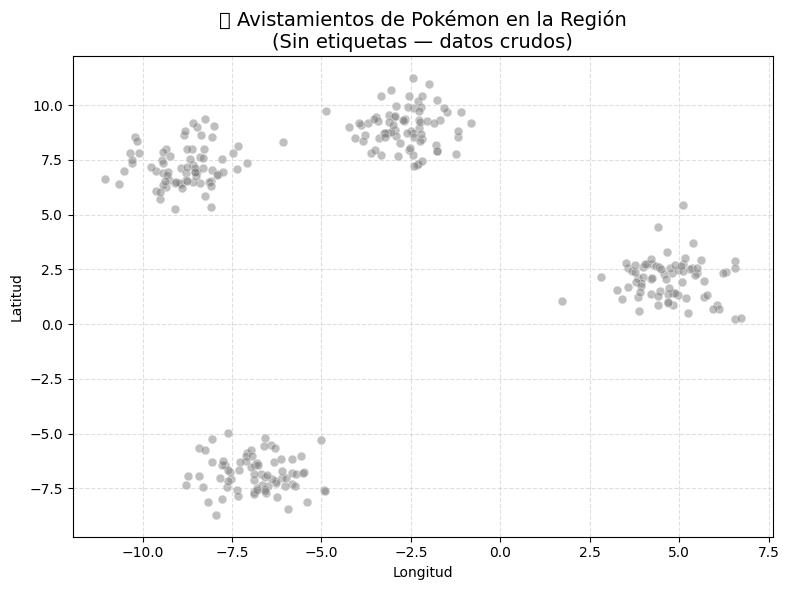

⚠️  El algoritmo NO tiene acceso a y_true. Tiene que descubrir los grupos solo.


In [3]:
# Español: Visualizamos los datos SIN etiquetas — así los ve K-Means
# English: Visualize the data WITHOUT labels — this is how K-Means sees it
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', alpha=0.5, s=40, edgecolors='white', linewidths=0.5)
plt.title('🗺️ Avistamientos de Pokémon en la Región\n(Sin etiquetas — datos crudos)', fontsize=14)
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print('⚠️  El algoritmo NO tiene acceso a y_true. Tiene que descubrir los grupos solo.')


### ⚙️ Paso 2 — Implementar K-Means con sklearn

In [4]:
# Español: Configuramos y entrenamos el modelo K-Means
# English: Configure and train the K-Means model
kmeans = KMeans(
    n_clusters=4, # Español: Número de clusters a encontrar; English: Number of clusters to find
    init='k-means++', # Español: Estrategia de inicialización de centroides; English: Centroid initialization strategy
    n_init=10, # Español: Veces que se reinicia el algoritmo; English: Number of times the algorithm runs with different centroid seeds
    max_iter=300, # Español: Máximo de iteraciones por ejecución; English: Maximum number of iterations per run
    random_state=RANDOM_STATE # Español: Semilla para reproducibilidad; English: Seed for reproducibility
)

# Español: .fit() ejecuta el algoritmo completo
# English: .fit() executes the complete algorithm
kmeans.fit(X)

print('✅ K-Means entrenado')
print(f'   Iteraciones hasta convergencia : {kmeans.n_iter_}')
print(f'   Etiquetas asignadas (primeras 10): {kmeans.labels_[:10]}')


✅ K-Means entrenado
   Iteraciones hasta convergencia : 3
   Etiquetas asignadas (primeras 10): [3 3 0 1 3 1 2 1 0 2]


In [5]:
# Español: Extraemos la información aprendida por el modelo
# English: Extract information learned by the model
labels     = kmeans.labels_           # Español: cluster asignado a cada punto; English: cluster assigned to each point
centroids  = kmeans.cluster_centers_  # Español: coordenadas de cada centroide; English: coordinates of each centroid

print('📍 Coordenadas de los 4 centroides (hábitats detectados):')
habitats = ['🌊 Acuático', '🌋 Volcánico', '🌿 Selvático', '🏔️ Montañoso'] # Español: Nombres para los hábitats; English: Names for the habitats
for i, (centroid, name) in enumerate(zip(centroids, habitats)):
    print(f'   Cluster {i} — {name}: ({centroid[0]:.2f}, {centroid[1]:.2f})')


📍 Coordenadas de los 4 centroides (hábitats detectados):
   Cluster 0 — 🌊 Acuático: (-2.65, 8.98)
   Cluster 1 — 🌋 Volcánico: (-6.84, -6.84)
   Cluster 2 — 🌿 Selvático: (4.71, 2.03)
   Cluster 3 — 🏔️ Montañoso: (-8.83, 7.20)


### 🎨 Paso 3 — Visualizar los Clusters y Centroides

C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 127755 (\N{VOLCANO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 127956 (\N{SNOW CAPPED MOUNTAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3071579274.py:46: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_la

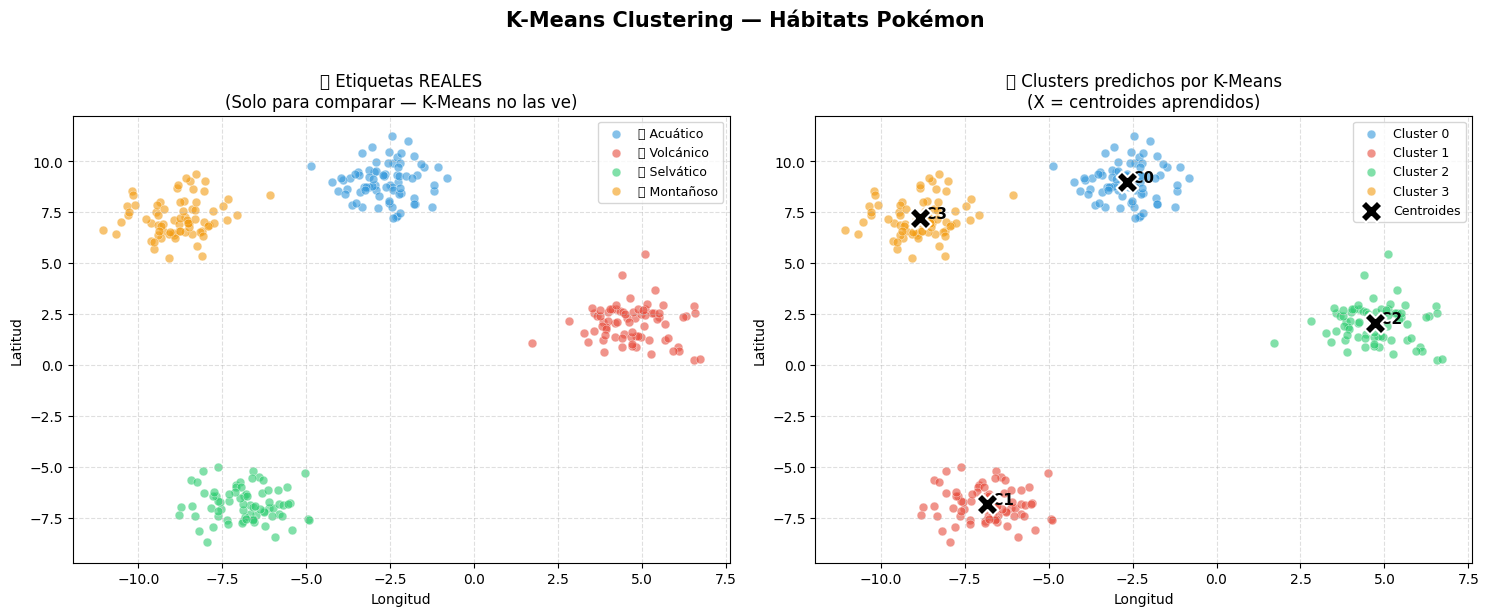

In [6]:
COLORES  = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12']  # Español: Colores para los clusters; English: Colors for the clusters
HABITATS = ['🌊 Acuático', '🌋 Volcánico', '🌿 Selvático', '🏔️ Montañoso'] # Español: Nombres de hábitats; English: Habitat names

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Izquierda: datos reales (y_true) ──────────────────────────────────────
# Left: real data (y_true)
ax = axes[0]
for k in range(4):
    mask = (y_true == k) # Español: Máscara para seleccionar puntos del cluster k; English: Mask to select points of cluster k
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORES[k], alpha=0.6, s=40,
               edgecolors='white', linewidths=0.4,
               label=HABITATS[k])
ax.set_title('✅ Etiquetas REALES\n(Solo para comparar — K-Means no las ve)', fontsize=12)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

# ── Derecha: clusters predichos por K-Means ────────────────────────────────
# Right: clusters predicted by K-Means
ax = axes[1]
for k in range(4):
    mask = (labels == k) # Español: Máscara para seleccionar puntos asignados por K-Means al cluster k; English: Mask to select points assigned by K-Means to cluster k
    ax.scatter(X[mask, 0], X[mask, 1],
               color=COLORES[k], alpha=0.6, s=40,
               edgecolors='white', linewidths=0.4,
               label=f'Cluster {k}')

# Español: Marcamos los centroides con una 'X' grande y visible
# English: Mark the centroids with a large, visible 'X'
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker='X', s=250, c='black',
           zorder=5, edgecolors='white', linewidths=1.5,
           label='Centroides')

# Español: Anotamos el número de cada centroide
# English: Annotate the number of each centroid
for i, centroid in enumerate(centroids):
    ax.annotate(f' C{i}', xy=centroid, fontsize=11, fontweight='bold', color='black')

ax.set_title('🤖 Clusters predichos por K-Means\n(X = centroides aprendidos)', fontsize=12)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('K-Means Clustering — Hábitats Pokémon', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 📐 Paso 4 — Inercia (SSE): ¿Qué tan compactos son los clusters?

In [7]:
# Español: La Inercia (también llamada SSE — Suma de Cuadrados de Errores) mide
# English: Inertia (also called SSE — Sum of Squared Errors) measures
# Español: la suma de distancias al cuadrado de cada punto a su centroide.
# English: the sum of squared distances of each point to its centroid.
#
#   Inercia baja  → puntos muy cercanos a sus centroides (clusters compactos) ✅
#   Low inertia   → points very close to their centroids (compact clusters) ✅
#   Inercia alta  → puntos dispersos, clusters poco definidos              ❌
#   High inertia  → dispersed points, poorly defined clusters              ❌
#
# sklearn la calcula y almacena en .inertia_ tras el fit()
# sklearn calculates and stores it in .inertia_ after fit()

inertia = kmeans.inertia_ # Español: Inercia calculada por sklearn; English: Inertia calculated by sklearn
print(f'📊 Inercia (SSE) con K=4: {inertia:.2f}')
print()
print('Cálculo manual para verificar:')
sse_manual = 0
for k in range(4):
    puntos_cluster = X[labels == k] # Español: Puntos que pertenecen al cluster k; English: Points belonging to cluster k
    centroide_k    = centroids[k] # Español: Centroide del cluster k; English: Centroid of cluster k
    distancias_sq  = np.sum((puntos_cluster - centroide_k) ** 2, axis=1) # Español: Distancia al cuadrado de cada punto al centroide; English: Squared distance of each point to the centroid
    sse_cluster    = np.sum(distancias_sq) # Español: SSE para el cluster actual; English: SSE for the current cluster
    sse_manual    += sse_cluster # Español: Suma de SSEs de todos los clusters; English: Sum of SSEs of all clusters
    print(f'   Cluster {k}: SSE parcial = {sse_cluster:.2f}  ({len(puntos_cluster)} puntos)')

print(f'   ─────────────────────────────')
print(f'   SSE total manual : {sse_manual:.2f}')
print(f'   kmeans.inertia_  : {inertia:.2f}')
print(f'   ¿Coinciden? {np.isclose(sse_manual, inertia)}')


📊 Inercia (SSE) con K=4: 458.75

Cálculo manual para verificar:
   Cluster 0: SSE parcial = 104.89  (75 puntos)
   Cluster 1: SSE parcial = 109.79  (75 puntos)
   Cluster 2: SSE parcial = 126.47  (75 puntos)
   Cluster 3: SSE parcial = 117.60  (75 puntos)
   ─────────────────────────────
   SSE total manual : 458.75
   kmeans.inertia_  : 458.75
   ¿Coinciden? True


### 💡 Resumen Parte 1

| Concepto | Definición rápida |
|---|---|
| **K** | Número de clusters que elige el usuario |
| **Centroide** | Punto medio de cada cluster (aprende en el entrenamiento) |
| **Asignación** | Cada punto va al centroide más cercano (distancia Euclídea) |
| **Inercia (SSE)** | Suma de distancias² punto→centroide. Menor es mejor |
| **k-means++** | Inicialización inteligente: centroides alejados entre sí → convergencia más estable |

> **Limitación clave:** K-Means necesita que le digas cuántos clusters quieres.  
> ¿Cómo elegir el K óptimo? → **Método del Codo** (tu turno en la Parte 2 👇)

---
# 🧪 PARTE 2 — Laboratorio

> **Instrucciones:** Completa las celdas marcadas con `# TODO`.  
> Cada TODO indica exactamente qué debes escribir. ¡Usa lo que aprendiste en la demo!

## 🗡️ Tarea 1 — El Método del Codo

**Contexto:** Volvemos a los datos de Hábitats Pokémon (`X`), pero esta vez **fingimos no saber que hay 4 grupos**.  
El Método del Codo nos ayuda a elegir el K óptimo graficando cómo cae la inercia al aumentar K.

**¿Por qué funciona?**  
- Al aumentar K, la inercia siempre baja (más centroides = puntos más cerca de su centroide).  
- Pero hay un punto donde añadir más K ya no mejora mucho → el **"codo"** de la curva.  
- Ese codo es nuestro K óptimo.

In [8]:
# Español: Inicializamos una lista para almacenar las inercias y definimos un rango de K
# English: Initialize a list to store inertias and define a range for K
inercias = []  # lista donde guardaremos la inercia para cada K; list where we will store inertia for each K
rango_k  = range(1, 11)  # K del 1 al 10; K from 1 to 10

for k in rango_k:
    # Español: Crea un modelo KMeans con el número actual de clusters (k)
    # English: Create a KMeans model with the current number of clusters (k)
    modelo = KMeans(
        n_clusters=k,
        init='k-means++', # Español: Método de inicialización; English: Initialization method
        n_init=10, # Español: Número de inicializaciones diferentes; English: Number of different initializations
        random_state=RANDOM_STATE # Español: Semilla para reproducibilidad; English: Seed for reproducibility
    )

    # Español: Entrena el modelo con los datos X
    # English: Train the model with the data X
    modelo.fit(X)

    # Español: Extrae la inercia del modelo entrenado y añádela a la lista
    # English: Extract the inertia from the trained model and add it to the list
    inercias.append(modelo.inertia_)

print('Inercias calculadas:', inercias)


Inercias calculadas:

 [19861.301898628353, 9308.011149550077, 2009.2112111594506, 458.75418039131273, 415.17652973250426, 372.86027589523053, 331.24737882396767, 295.1216978528947, 264.55116309486635, 234.94257309075184]


C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\2923539128.py:20: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


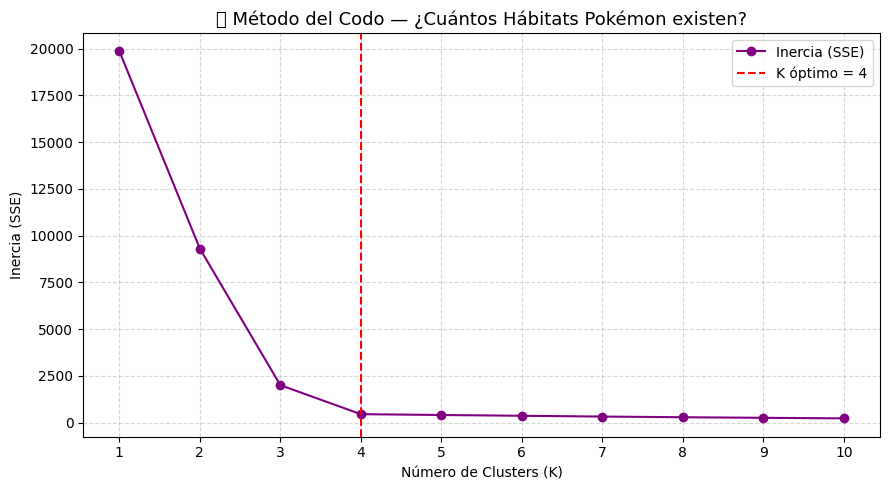

📝 Mi conclusión: En el gráfico, el "codo" más pronunciado se observa en K=4. Esto coincide perfectamente con el número real de 4 hábitats que generamos para los datos de Pokémon, demostrando la efectividad del método del codo para identificar el número óptimo de clusters.


In [9]:
# ── Tarea 1 (continuación): Graficar el Método del Codo ───────────────────
# Task 1 (continuation): Plot the Elbow Method

plt.figure(figsize=(9, 5))

# Español: Grafica rango_k en el eje X e inercias en el eje Y
# English: Plot rango_k on the X-axis and inertias on the Y-axis
plt.plot(rango_k, inercias, 'o-', color='purple', label='Inercia (SSE)')

# Español: Añade una línea vertical punteada en el K óptimo que detectes
# English: Add a dashed vertical line at the optimal K you detect
plt.axvline(x=4, color='red', linestyle='--', label='K óptimo = 4')

plt.title('📐 Método del Codo — ¿Cuántos Hábitats Pokémon existen?', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (SSE)')
plt.xticks(list(rango_k))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Español: Escribe aquí tu conclusión sobre el K óptimo
# English: Write your conclusion here about the optimal K
print('📝 Mi conclusión: En el gráfico, el "codo" más pronunciado se observa en K=4. Esto coincide perfectamente con el número real de 4 hábitats que generamos para los datos de Pokémon, demostrando la efectividad del método del codo para identificar el número óptimo de clusters.')


---
## 🍓 Tarea 2 — Dataset de Bayas Pokémon

**Historia:** El Professor Oak ha recolectado **210 muestras de bayas silvestres** de toda la región.  
Midió 7 características físicas de cada baya, pero **no las clasificó** porque no tiene tiempo.  
Tu misión: usar K-Means para descubrir **cuántos tipos de bayas existen**.

*(Dataset basado en el clásico Seeds Dataset de UCI — trigo → bayas Pokémon)*

**Características medidas:**

| Columna | Descripción |
|---|---|
| `area` | Área de la baya (mm²) |
| `perimetro` | Perímetro (mm) |
| `compacidad` | Índice de forma circular |
| `longitud_nucleo` | Longitud del núcleo (mm) |
| `ancho_nucleo` | Ancho del núcleo (mm) |
| `coef_asimetria` | Coeficiente de asimetría |
| `longitud_surco` | Longitud del surco central (mm) |

In [10]:
# Español: Cargamos el dataset de Bayas Pokémon (basado en Seeds Dataset de UCI)
# English: Load the Pokémon Berries dataset (based on UCI Seeds Dataset)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt'

columnas = ['area', 'perimetro', 'compacidad',
            'longitud_nucleo', 'ancho_nucleo',
            'coef_asimetria', 'longitud_surco', 'tipo_real']

df_bayas = pd.read_csv(url, sep=r'\s+', header=None, names=columnas)

# Español: Separamos las características (features) y la etiqueta real (solo para comparar al final)
# English: Separate features and the real label (only for comparison at the end)
X_bayas   = df_bayas.drop(columns='tipo_real').values
y_bayas   = df_bayas['tipo_real'].values

print(f'Dataset de Bayas Pokémon cargado: {df_bayas.shape[0]} muestras, {X_bayas.shape[1]} features')
df_bayas.drop(columns='tipo_real').describe().round(2)


Dataset de Bayas Pokémon cargado: 210 muestras, 7 features


,area,perimetro,compacidad,longitud_nucleo,ancho_nucleo,coef_asimetria,longitud_surco
count,210.00,210.00,210.00,210.00,210.00,210.00,210.00
mean,14.85,14.56,0.87,5.63,3.26,3.70,5.41
std,2.91,1.31,0.02,0.44,0.38,1.50,0.49
min,10.59,12.41,0.81,4.90,2.63,0.77,4.52
25%,12.27,13.45,0.86,5.26,2.94,2.56,5.04
50%,14.36,14.32,0.87,5.52,3.24,3.60,5.22
75%,17.30,15.72,0.89,5.98,3.56,4.77,5.88
max,21.18,17.25,0.92,6.68,4.03,8.46,6.55


C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\465112797.py:36: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127827 (\N{STRAWBERRY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


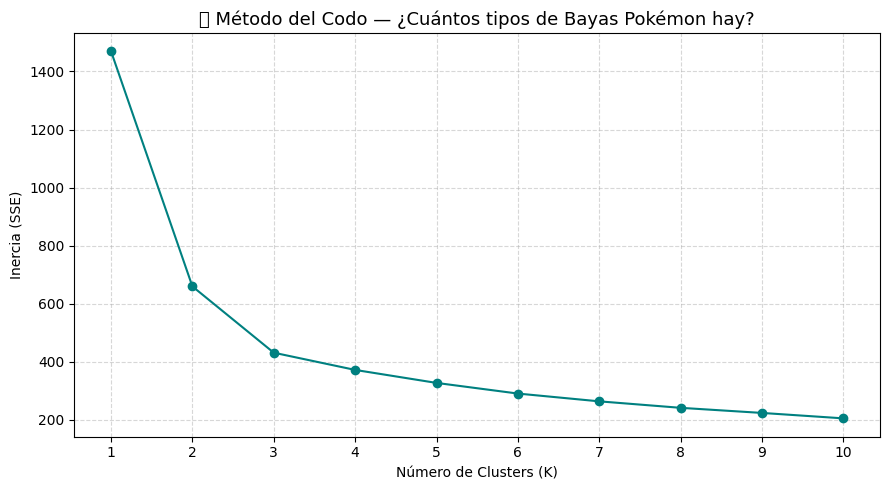

📝 Según el gráfico, el K óptimo parece ser: 3. Se observa un codo pronunciado en este punto, y la mejora en la inercia disminuye significativamente a partir de ahí.


In [11]:
# ── Tarea 2a: Método del Codo para las Bayas ──────────────────────────────
# Task 2a: Elbow Method for Berries
# Antes de aplicar K-Means, DEBES escalar los datos.
# Before applying K-Means, you MUST scale the data.
# (Verás POR QUÉ en la sección final — por ahora hazlo sin cuestionarlo)
# (You'll see WHY in the final section — for now, do it without questioning)

# Español: Crea un StandardScaler y ajústalo+transfórmalo sobre X_bayas
# English: Create a StandardScaler and fit+transform it on X_bayas
scaler = StandardScaler()
X_bayas_scaled = scaler.fit_transform(X_bayas)

# Español: Calcula la inercia para K = 1 al 10 usando X_bayas_scaled
# English: Calculate inertia for K = 1 to 10 using X_bayas_scaled
inercias_bayas = []

for k in range(1, 11):
    modelo_bayas = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=RANDOM_STATE
    )
    modelo_bayas.fit(X_bayas_scaled)
    inercias_bayas.append(modelo_bayas.inertia_)

# Español: Grafica el Método del Codo para las bayas
# English: Plot the Elbow Method for berries
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inercias_bayas, 'o-', color='teal', label='Inercia (SSE)')
plt.title('🍓 Método del Codo — ¿Cuántos tipos de Bayas Pokémon hay?', fontsize=13)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (SSE)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('📝 Según el gráfico, el K óptimo parece ser: 3. Se observa un codo pronunciado en este punto, y la mejora en la inercia disminuye significativamente a partir de ahí.')


In [12]:
# ── Tarea 2b: Aplicar K-Means con el K óptimo ─────────────────────────────
# Task 2b: Apply K-Means with the optimal K

# Español: Entrena KMeans con el K que elegiste en la Tarea 2a
# English: Train KMeans with the K you chose in Task 2a
K_optimo   = 3   # Español: Valor de K óptimo; English: Optimal K value
kmeans_bayas = KMeans(
    n_clusters=K_optimo,
    init='k-means++',
    n_init=10,
    random_state=RANDOM_STATE
)
kmeans_bayas.fit(X_bayas_scaled)  # Español: Entrenar el modelo; English: Train the model

# Español: Obtén las etiquetas predichas y guárdalas en labels_bayas
# English: Get the predicted labels and store them in labels_bayas
labels_bayas = kmeans_bayas.labels_  # Español: Obtener las etiquetas de los clusters; English: Get the cluster labels

# Español: Comparación con las etiquetas reales (el dataset tiene 3 tipos)
# English: Comparison with real labels (the dataset has 3 types)
df_resultado = df_bayas.drop(columns='tipo_real').copy()
df_resultado['cluster_kmeans'] = labels_bayas
df_resultado['tipo_real']      = y_bayas

print('📊 Distribución de tipos reales vs clusters encontrados:')
print(pd.crosstab(df_resultado['tipo_real'], df_resultado['cluster_kmeans'],
                  rownames=['Tipo Real'], colnames=['Cluster K-Means']))


📊 Distribución de tipos reales vs clusters encontrados:
Cluster K-Means   0   1   2
Tipo Real                  
1                 6   2  62
2                 0  65   5
3                66   0   4


C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\2470676734.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\2470676734.py:32: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


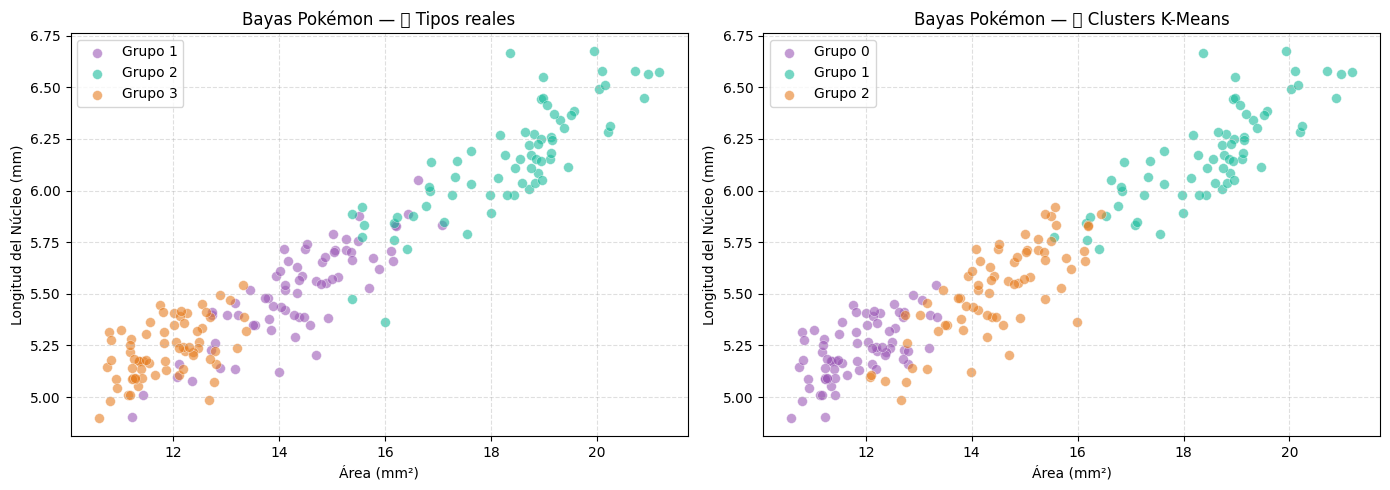

In [13]:
# ── Tarea 2c (Bonus): Visualizar las Bayas en 2D ──────────────────────────
# Task 2c (Bonus): Visualize Berries in 2D
# Español: Como tenemos 7 dimensiones, usamos solo las 2 más representativas para visualizar
# English: Since we have 7 dimensions, we use only the 2 most representative for visualization

# Español: Grafica un scatter plot de 'area' vs 'longitud_nucleo'
# English: Plot a scatter plot of 'area' vs 'longitud_nucleo'
# Español: coloreando por cluster_kmeans y compara con tipo_real
# English: coloring by cluster_kmeans and compare with tipo_real

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORES_B = ['#9B59B6', '#1ABC9C', '#E67E22'] # Español: Colores para las bayas; English: Colors for the berries

for ax, col_color, titulo in zip(axes,
                                  ['tipo_real', 'cluster_kmeans'],
                                  ['✅ Tipos reales', '🤖 Clusters K-Means']):
    grupos = df_resultado[col_color].unique()
    for g, color in zip(sorted(grupos), COLORES_B):
        mask = df_resultado[col_color] == g # Español: Máscara para seleccionar puntos del grupo actual; English: Mask to select points of the current group
        ax.scatter(df_resultado.loc[mask, 'area'], # Español: Eje X: 'area'; English: X-axis: 'area'
                   df_resultado.loc[mask, 'longitud_nucleo'], # Español: Eje Y: 'longitud_nucleo'; English: Y-axis: 'longitud_nucleo'
                   color=color, alpha=0.6, s=50,
                   edgecolors='white', linewidths=0.4,
                   label=f'Grupo {g}')

    ax.set_title(f'Bayas Pokémon — {titulo}', fontsize=12)
    ax.set_xlabel('Área (mm²)')
    ax.set_ylabel('Longitud del Núcleo (mm)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


---
## ⚖️ Sección Final — ¿Por qué StandardScaler es ESENCIAL antes de K-Means?

K-Means mide **distancias**. Si una variable tiene valores en miles y otra en decimales,  
la primera dominará completamente el cálculo, **aunque no sea más importante**.

StandardScaler transforma cada variable a **media=0, desviación estándar=1**,  
poniendo todas en el mismo campo de juego.

C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3943572176.py:49: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\majo1\AppData\Local\Temp\ipykernel_21612\3943572176.py:49: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\majo1\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


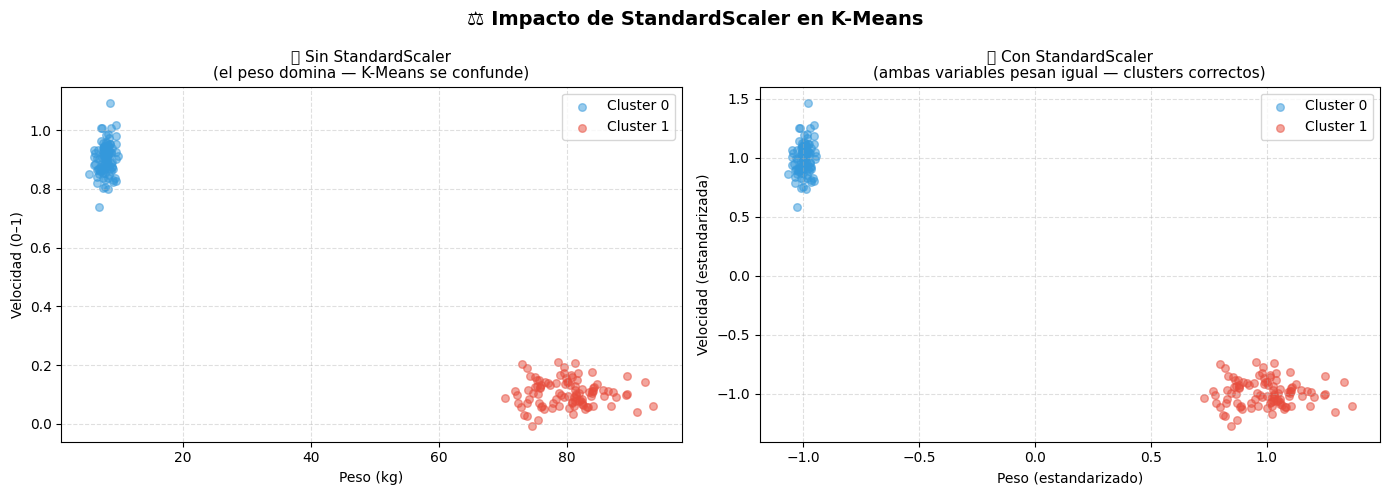

In [14]:
# ── Demostración: efecto de no escalar ────────────────────────────────────
# Demonstration: effect of not scaling
np.random.seed(42)
n = 100

# Español: Dataset Pokémon simulado: Peso (kg, escala grande) y Velocidad (0-1, escala pequeña)
# English: Simulated Pokémon dataset: Weight (kg, large scale) and Speed (0-1, small scale)
peso      = np.concatenate([np.random.normal(8,   1,   n),   # Español: Pokémon ligeros; English: Light Pokémon
                             np.random.normal(80,  5,   n)])  # Español: Pokémon pesados; English: Heavy Pokémon
velocidad = np.concatenate([np.random.normal(0.9, 0.05, n),  # Español: rápidos; English: fast
                             np.random.normal(0.1, 0.05, n)]) # Español: lentos; English: slow

# Español: Nótese que los ligeros son rápidos y los pesados son lentos → 2 grupos claros
# English: Note that light ones are fast and heavy ones are slow → 2 clear groups
X_demo = np.column_stack([peso, velocidad])

# Español: K-Means SIN escalar
# English: K-Means WITHOUT scaling
km_sin  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_demo)

# Español: K-Means CON escalar
# English: K-Means WITH scaling
scaler  = StandardScaler()
X_scaled_demo = scaler.fit_transform(X_demo)
km_con  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X_scaled_demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels_plot, X_plot, km_plot, xlabel, ylabel, titulo in zip(
        axes,
        [km_sin.labels_, km_con.labels_],
        [X_demo, X_scaled_demo],
        [km_sin, km_con],
        ['Peso (kg)', 'Peso (estandarizado)'],
        ['Velocidad (0–1)', 'Velocidad (estandarizada)'],
        ['❌ Sin StandardScaler\n(el peso domina — K-Means se confunde)',
         '✅ Con StandardScaler\n(ambas variables pesan igual — clusters correctos)']):

    for k, color in zip([0, 1], ['#3498DB', '#E74C3C']):
        mask = labels_plot == k # Español: Máscara para seleccionar puntos del cluster k; English: Mask to select points of cluster k
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   color=color, alpha=0.5, s=30, label=f'Cluster {k}')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('⚖️ Impacto de StandardScaler en K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── Visualización del efecto del scaler sobre los datos ───────────────────
# Visualization of the scaler's effect on the data
print('📊 Estadísticas ANTES del escalado:') # Español: Estadísticas antes del escalado; English: Statistics before scaling
df_sin = pd.DataFrame(X_demo, columns=['Peso (kg)', 'Velocidad'])
print(df_sin.describe().round(3))

print('\n📊 Estadísticas DESPUÉS del escalado:') # Español: Estadísticas después del escalado; English: Statistics after scaling
df_con = pd.DataFrame(X_scaled_demo, columns=['Peso (scaled)', 'Velocidad (scaled)'])
print(df_con.describe().round(3))

print()
print('🔑 Regla de oro:') # Español: Regla de oro; English: Golden rule
print('   Siempre aplica StandardScaler (o MinMaxScaler) antes de K-Means')
print('   cuando tus features tienen diferentes unidades o escalas.')


📊 Estadísticas ANTES del escalado:
       Peso (kg)  Velocidad
count    200.000    200.000
mean      44.004      0.504
std       36.360      0.403
min        5.380     -0.006
25%        7.879      0.103
50%       40.129      0.474
75%       80.382      0.904
max       93.601      1.093

📊 Estadísticas DESPUÉS del escalado:
       Peso (scaled)  Velocidad (scaled)
count        200.000             200.000
mean           0.000              -0.000
std            1.003               1.003
min           -1.065              -1.270
25%           -0.996              -0.998
50%           -0.107              -0.076
75%            1.003               0.996
max            1.367               1.464

🔑 Regla de oro:
   Siempre aplica StandardScaler (o MinMaxScaler) antes de K-Means
   cuando tus features tienen diferentes unidades o escalas.


---
## 🏆 Resumen Final

| Concepto | Lo que aprendiste |
|---|---|
| **K-Means** | Algoritmo iterativo que minimiza la inercia agrupando puntos por cercanía al centroide |
| **Inercia (SSE)** | Métrica de compacidad: suma de distancias² punto→centroide |
| **Método del Codo** | Técnica para elegir K: busca el quiebre en la curva Inercia vs K |
| **k-means++** | Inicialización que evita mínimos locales malos |
| **StandardScaler** | **Obligatorio** cuando features tienen diferentes escalas |

### Próximos pasos
- **DBSCAN**: clustering que encuentra clusters de forma arbitraria y detecta outliers.
- **Clustering Jerárquico**: no necesita K predefinido, produce un dendrograma.
- **PCA + K-Means**: reducir dimensionalidad antes de clustering para datasets de alta dimensión.

> *"El aprendizaje no supervisado es como ser el Professor Oak: explorar el mundo Pokémon sin que nadie te diga qué encontrarás."*